GREENAUDIT COMPLETE AI + OPTIMIZATION SYSTEM

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.optimize import minimize

1. LOAD DATA

In [3]:
df = pd.read_csv("converted_file.csv")


2. CARBON EMISSION FORMULA


In [4]:
EF_ELECTRICITY = 0.82
EF_WATER = 0.0003
EF_CAR = 0.21
EF_PUBLIC = 0.11

def transport_factor(mode):
    if mode == "Car":
        return EF_CAR
    elif mode == "Public_Transport":
        return EF_PUBLIC
    else:
        return 0

df["Transport_Factor"] = df["Transportation_Mode"].apply(transport_factor)

df["Calculated_Carbon"] = (
    df["Energy_Usage_kWh_per_Month"] * EF_ELECTRICITY +
    df["Water_Usage_Liters_per_Day"] * 30 * EF_WATER +
    df["Transport_Factor"] * 100
)



In [18]:
from sklearn.model_selection import cross_val_score

cv_model = RandomForestRegressor(n_estimators=100)

cv_scores = cross_val_score(cv_model, X, y, cv=5, scoring='r2')

print("Cross Validation R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

Cross Validation R2 Scores: [0.99910049 0.99931072 0.99915048 0.99875998 0.99923992]
Average CV R2: 0.9991123168903309


3. MACHINE LEARNING


In [7]:
print(df.isnull().sum())
df = df.dropna()
target = "Calculated_Carbon"

X = df.drop(target, axis=1)
y = df[target]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models (reduced complexity for speed)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, max_depth=4)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

ensemble_pred = (lr_pred + rf_pred + xgb_pred) / 3


comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": ensemble_pred
})

print(comparison.head(60))

Clothing_Spend_per_Month       0
Food_Type                      0
Housing_Type                   0
Energy_Usage_kWh_per_Month     0
Water_Usage_Liters_per_Day     0
Transportation_Mode            0
Consumption_Spend_per_Month    0
Recycling_Habits               0
Carbon_Emissions_kgCO2         0
Transport_Factor               0
Calculated_Carbon              0
dtype: int64
     Actual   Predicted
0   368.385  370.676589
1   155.793  154.458038
2   354.379  355.494427
3   352.833  354.101045
4   294.386  295.082502
5    95.601   96.161858
6   180.195  180.314138
7    93.730   94.348298
8   325.543  317.970644
9   383.240  382.238385
10  193.453  194.851226
11   90.911   91.977692
12  351.377  348.691868
13  308.683  306.080454
14  360.371  360.446962
15  279.253  278.886078
16  345.937  348.463549
17  323.935  317.978795
18   63.806   64.838662
19   77.995   79.280030
20  131.352  131.152847
21  396.193  398.151653
22  162.101  159.572958
23  411.569  411.518243
24  178.187  179.000433


4. Evaluation and OVERFITTING CHECK

In [8]:
from sklearn.metrics import r2_score, mean_absolute_error

# Calculate ensemble predictions for the training set
lr_train_pred = lr.predict(X_train)
rf_train_pred = rf.predict(X_train)
xgb_train_pred = xgb.predict(X_train)
ensemble_train_pred = (lr_train_pred + rf_train_pred + xgb_train_pred) / 3

# Training predictions
train_pred = ensemble_train_pred

# Testing predictions (ensemble_pred is already calculated for X_test)
test_pred = ensemble_pred

print("Training R2:", r2_score(y_train, train_pred))
print("Testing R2:", r2_score(y_test, test_pred))

print("Training MAE:", mean_absolute_error(y_train, train_pred))
print("Testing MAE:", mean_absolute_error(y_test, test_pred))

Training R2: 0.999979391318475
Testing R2: 0.9996450345907815
Training MAE: 0.38645742974803954
Testing MAE: 1.5003658667277258


5. VISUAL: Actual vs Predicted


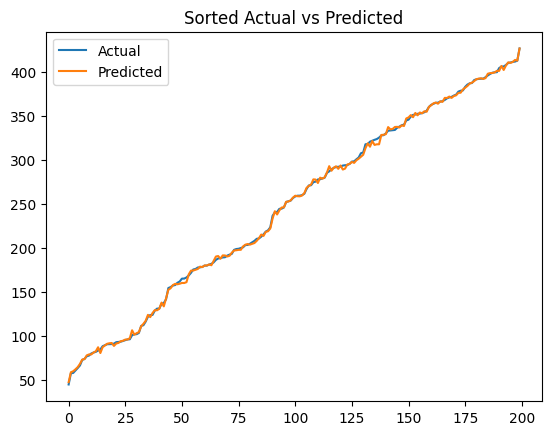

In [9]:
sorted_idx = y_test.argsort()
plt.figure()
plt.plot(y_test.values[sorted_idx], label="Actual")
plt.plot(ensemble_pred[sorted_idx], label="Predicted")
plt.legend()
plt.title("Sorted Actual vs Predicted")
plt.show()


6 LEARNING CURVE (Random Forest Regressor)

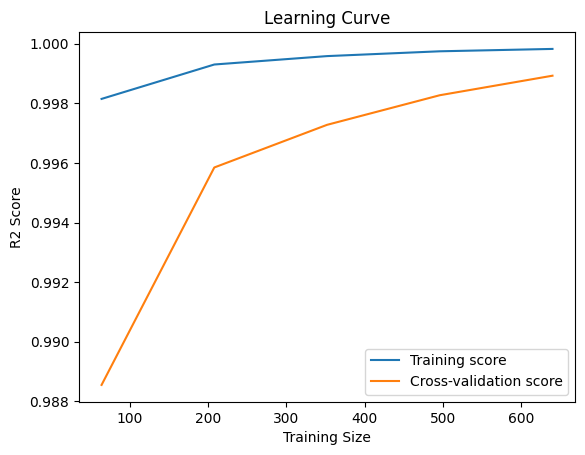

In [10]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plot
plt.figure()
plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, test_mean, label="Cross-validation score")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve")
plt.legend(loc="best")
plt.show()

Learning Curve — Linear Regression

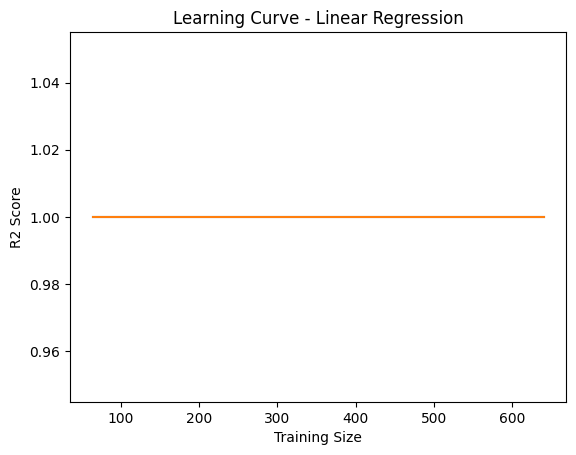

In [11]:

lr_model = LinearRegression()

train_sizes, train_scores, test_scores = learning_curve(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure()
plt.plot(train_sizes, train_mean)
plt.plot(train_sizes, test_mean)
plt.title("Learning Curve - Linear Regression")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.show()

Learning Curve — XGBoost

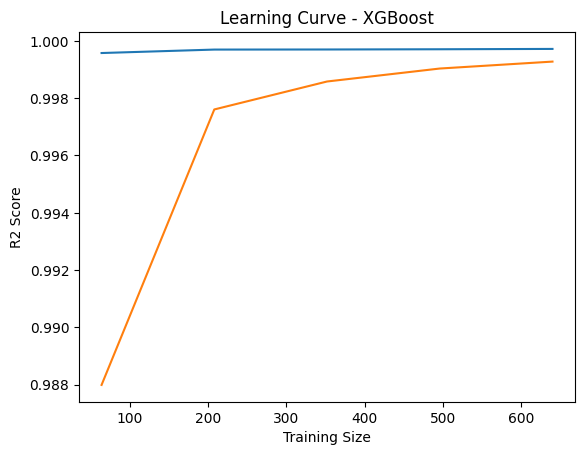

In [12]:
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

train_sizes, train_scores, test_scores = learning_curve(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure()
plt.plot(train_sizes, train_mean)
plt.plot(train_sizes, test_mean)
plt.title("Learning Curve - XGBoost")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.show()

BIAS–VARIANCE TRADEOFF (Rabdom Forest Regressor)

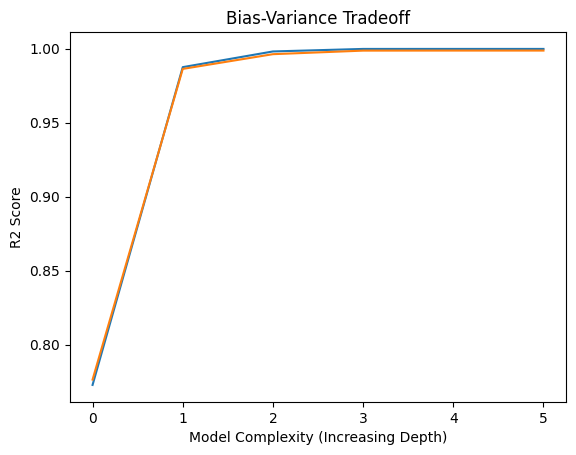

In [13]:
from sklearn.metrics import r2_score

depths = [1, 3, 5, 10, 20, None]

train_scores = []
test_scores = []

for depth in depths:
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(r2_score(y_train, model.predict(X_train)))
    test_scores.append(r2_score(y_test, model.predict(X_test)))

# Plot
plt.figure()
plt.plot(range(len(depths)), train_scores)
plt.plot(range(len(depths)), test_scores)
plt.xlabel("Model Complexity (Increasing Depth)")
plt.ylabel("R2 Score")
plt.title("Bias-Variance Tradeoff")
plt.show()

Bias–Variance — Linear Regression

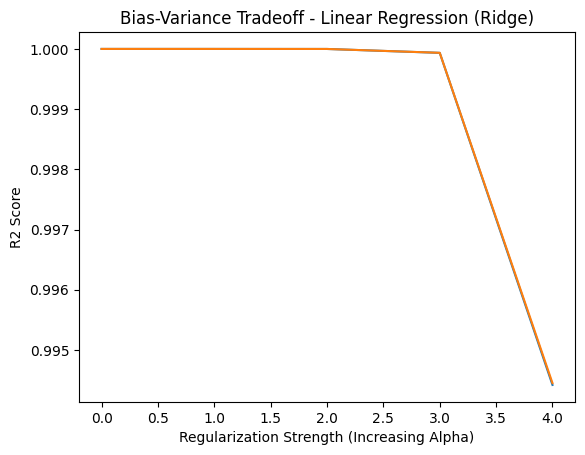

In [14]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

alphas = [0.01, 0.1, 1, 10, 100]

train_scores = []
test_scores = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    train_scores.append(r2_score(y_train, model.predict(X_train)))
    test_scores.append(r2_score(y_test, model.predict(X_test)))

plt.figure()
plt.plot(range(len(alphas)), train_scores)
plt.plot(range(len(alphas)), test_scores)
plt.title("Bias-Variance Tradeoff - Linear Regression (Ridge)")
plt.xlabel("Regularization Strength (Increasing Alpha)")
plt.ylabel("R2 Score")
plt.show()

Bias–Variance — XGBoost

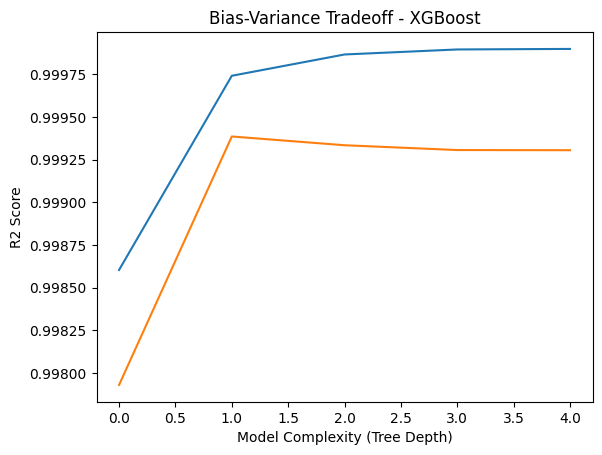

In [15]:
depths = [2, 4, 6, 8, 10]

train_scores = []
test_scores = []

for depth in depths:
    model = XGBRegressor(
        n_estimators=100,
        max_depth=depth,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(r2_score(y_train, model.predict(X_train)))
    test_scores.append(r2_score(y_test, model.predict(X_test)))

plt.figure()
plt.plot(range(len(depths)), train_scores)
plt.plot(range(len(depths)), test_scores)
plt.title("Bias-Variance Tradeoff - XGBoost")
plt.xlabel("Model Complexity (Tree Depth)")
plt.ylabel("R2 Score")
plt.show()

6. TIME SERIES FORECAST


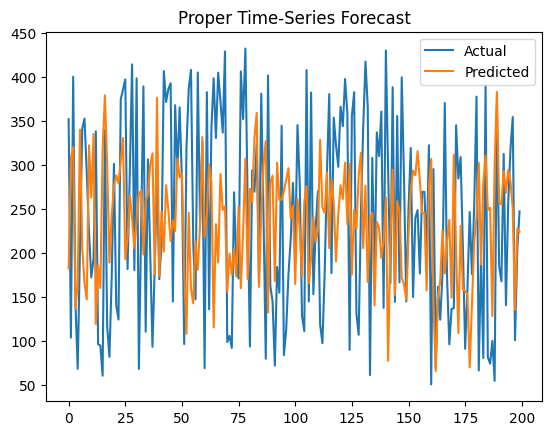

In [16]:
# Create lag features
df["Lag1"] = df[target].shift(1)
df["Lag2"] = df[target].shift(2)
df = df.dropna()

X_ts = df[["Lag1", "Lag2"]]
y_ts = df[target]

# Chronological split (NO shuffle)
train_size = int(len(df) * 0.8)

X_train_ts = X_ts[:train_size]
X_test_ts = X_ts[train_size:]

y_train_ts = y_ts[:train_size]
y_test_ts = y_ts[train_size:]

# Train
xgb_ts = XGBRegressor(n_estimators=100)
xgb_ts.fit(X_train_ts, y_train_ts)

# Predict ONLY on unseen future data
y_pred_ts = xgb_ts.predict(X_test_ts)

# Plot
plt.figure()
plt.plot(y_test_ts.values, label="Actual")
plt.plot(y_pred_ts, label="Predicted")
plt.legend()
plt.title("Proper Time-Series Forecast")
plt.show()

7. OPTIMIZATION

Baseline Carbon: 247.17371543086173
Optimized Carbon: 122.32837154299737


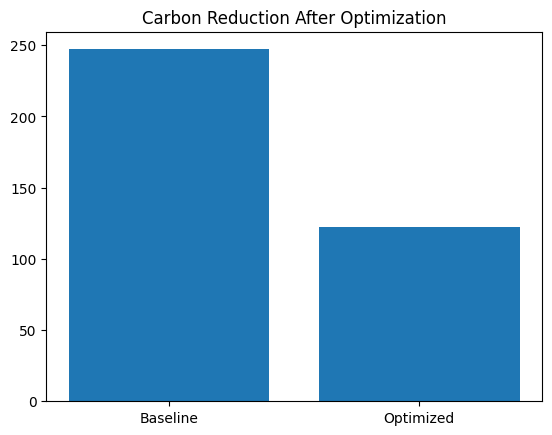

In [17]:
avg_energy = df["Energy_Usage_kWh_per_Month"].mean()
avg_water = df["Water_Usage_Liters_per_Day"].mean()

def carbon_objective(x):
    energy, water, transport = x
    return (
        energy * EF_ELECTRICITY +
        water * 30 * EF_WATER +
        transport * 0.15
    )

constraints = [
    {'type': 'ineq', 'fun': lambda x: x[0] - 0.5 * avg_energy},
    {'type': 'ineq', 'fun': lambda x: x[1] - 0.6 * avg_water},
    {'type': 'ineq', 'fun': lambda x: x[2] - 40}
]

x0 = [avg_energy, avg_water, 100]

result = minimize(carbon_objective, x0, constraints=constraints)

print("Baseline Carbon:", carbon_objective(x0))
print("Optimized Carbon:", carbon_objective(result.x))

plt.figure()
plt.bar(["Baseline", "Optimized"],
        [carbon_objective(x0), carbon_objective(result.x)])
plt.title("Carbon Reduction After Optimization")
plt.show()